In [1]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from driver_genes.data.utils import compute_pred
from driver_genes.viutils import valid_filename, get_palette, adjust_color

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
sns.set_theme(style="ticks")


In [2]:
our_dir = '../results'
ad_id = sc.read_h5ad(f'{our_dir}/kowalski/hek293ft_noisy-seed42/anndata/preprocessed_noisy_HEK293FT_R1_true.h5ad')
compute_pred(ad_id)

AnnData object with n_obs × n_vars = 34000 × 22385
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'perturbation', 'mixscape_class', 'mixscape_class.global', 'cellline', 'n_genes', 'replicate+lane', 'leiden', 'cluster', 'perturbation_true', 'bc', 'pred_perturbation'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_raw', 'highly_variable_batch'
    uns: 'cellline_colors', 'cluster_colors', 'hvg', 'lane_colors', 'leiden', 'log1p', 'neighbors', 'pca', 'pertgenes', 'perturbation_colors', 'replicate+lane_colors', 'replicate_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'latent', 'proba', 'shift', 'rank', 'RelPos', 'logit'
    varm: 'PCs'
    layers: 'X_hat', 'dy', 'raw'
    obsp: 'connectivities', 'distances'

In [3]:
ad_id_d = ad_id[
    (ad_id.obs['perturbation'].values.astype(str) != ad_id.obs['perturbation_true'].values.astype(str)) & 
    ~(ad_id.obs['perturbation_true'].isin(['neg', 'control']))
].copy()
ad_id_d

AnnData object with n_obs × n_vars = 1676 × 22385
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'perturbation', 'mixscape_class', 'mixscape_class.global', 'cellline', 'n_genes', 'replicate+lane', 'leiden', 'cluster', 'perturbation_true', 'bc', 'pred_perturbation'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_raw', 'highly_variable_batch'
    uns: 'cellline_colors', 'cluster_colors', 'hvg', 'lane_colors', 'leiden', 'log1p', 'neighbors', 'pca', 'pertgenes', 'perturbation_colors', 'replicate+lane_colors', 'replicate_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'latent', 'proba', 'shift', 'rank', 'RelPos', 'logit'
    varm: 'PCs'
    layers: 'X_hat', 'dy', 'raw'
    obsp: 'connectivities', 'distances'

In [4]:
pert2idx = {pert: idx for idx, pert in enumerate(ad_id_d.obsm['RelPos'].columns)}

In [5]:
logit_df_cellnavi = pd.read_csv('../cellnavi/data/dataset2/kowalski_noisy/HEK293FT/test_id_3000_results.csv', index_col=0).drop(columns=['control'])
relpos_id_cellnavi = (
    logit_df_cellnavi.iloc[:, :len(pert2idx)]
    .rank(axis=1, ascending=False)
    .transform(lambda x: (len(pert2idx) - x + 1) / len(pert2idx))
)

In [6]:
corr_df_gears = pd.read_parquet('../benchmark/notebooks/gears/models/kowalski_noisy_trainonhek293ft/epoch_results_id_true.parquet')
relpos_id_gears = (
    corr_df_gears.iloc[:, :len(pert2idx)]
    .rank(axis=1, ascending=False)
    .transform(lambda x: (len(pert2idx) - x + 1) / len(pert2idx))
)
diff_mask = corr_df_gears['perturbation_true'].astype(str).values != corr_df_gears['perturbation'].astype(str).values
corr_df_gears = corr_df_gears.loc[diff_mask]
relpos_id_gears = relpos_id_gears.loc[diff_mask]

In [7]:
ad_id_d.obsm['proba'].index.str.split('-').str[:2].str.join('-').values

array(['R1-L1_TGGTACACAGTTCTAG', 'R1-L2_GTGCTTCTCGCAGATT',
       'R1-L1_TATACCTCACGTCATA', ..., 'R1-L1_CGATCGGGTCTGTGTA',
       'R1-L1_TTCGGTCGTTTGAAAG', 'R1-L2_TCATCATAGTCAAGCG'], dtype=object)

In [8]:
relpos_df = pd.concat([
    pd.DataFrame({
        'corrupted': ad_id_d.obsm['RelPos'].values[np.arange(ad_id_d.n_obs), ad_id_d.obs['perturbation'].map(pert2idx).values.astype(int)],
        'original': ad_id_d.obsm['RelPos'].values[np.arange(ad_id_d.n_obs), ad_id_d.obs['perturbation_true'].map(pert2idx).values.astype(int)],
        'Model': 'Ours'
    }),
    pd.DataFrame({
        'corrupted': [relpos_id_cellnavi.loc[i,j] for i, j in zip(
            ad_id_d.obsm['proba'].index.str.split('-').str[:2].str.join('-').values, 
            ad_id_d.obs['perturbation'].values
        )],
        'original': [relpos_id_cellnavi.loc[i,j] for i, j in zip(
            ad_id_d.obsm['proba'].index.str.split('-').str[:2].str.join('-').values, 
            ad_id_d.obs['perturbation_true'].values
        )],
        'Model': 'CellNavi'
    }),
    pd.DataFrame({
        'corrupted': relpos_id_gears.values[np.arange(relpos_id_gears.shape[0]), corr_df_gears['perturbation'].map(pert2idx).values.astype(int)],
        'original': relpos_id_gears.values[np.arange(relpos_id_gears.shape[0]), corr_df_gears['perturbation_true'].map(pert2idx).values.astype(int)],
        'Model': 'GEARS'
    })
    
])


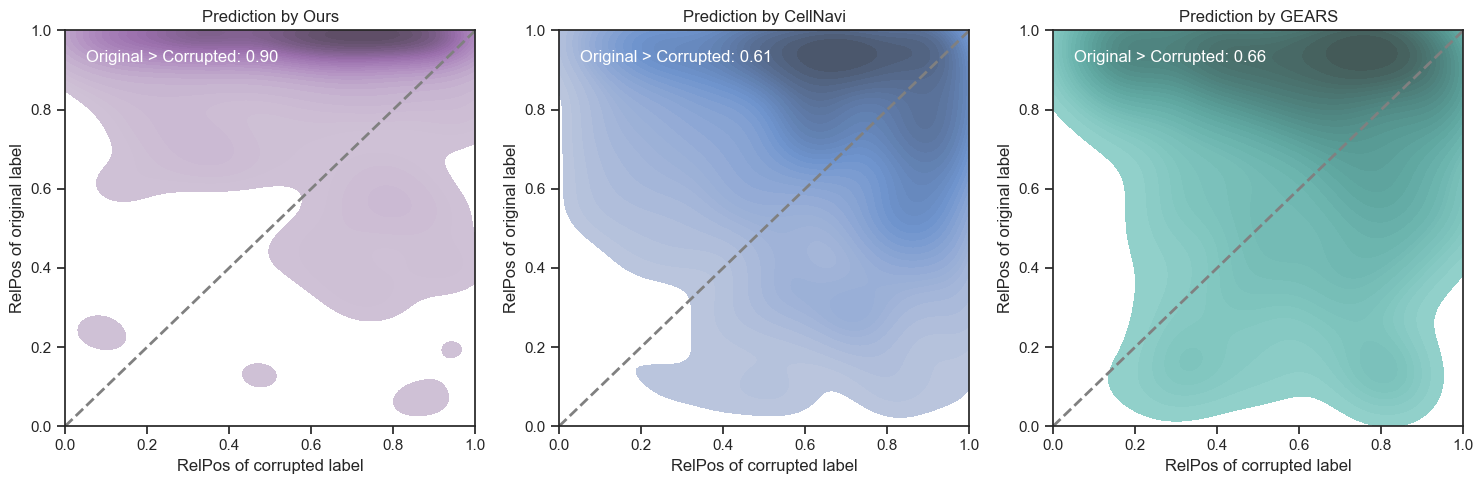

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for model, ax in zip(['Ours', 'CellNavi', 'GEARS'], axes):
    plot_df = relpos_df.query(f'Model == "{model}"')
    sns.kdeplot(
        data=plot_df, 
        x='corrupted', 
        y='original', 
        hue='Model',
        hue_order=['Ours', 'CellNavi', 'GEARS'],
        fill=True, 
        bins=25,
        ax=ax,
        palette=get_palette().colors[:3],
        levels=30,
    )
    ori_ratio = (plot_df['original'] > plot_df['corrupted']).mean()
    cor_ratio = (plot_df['corrupted'] > plot_df['original']).mean()
    ax.text(0.05, 0.95, f'Original > Corrupted: {ori_ratio:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', color='white')
    # ax.text(0.95, 0.05, f'Corr > Ori: {cor_ratio:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='bottom', horizontalalignment='right')
    ax.legend().remove()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.plot([0, 1], [0, 1], ls='--', color='grey', lw=2)
    ax.set_title('Prediction by ' + model)
    ax.set_ylabel('RelPos of original label')
    ax.set_xlabel('RelPos of corrupted label')
fig.tight_layout()
fig.savefig('../figures/5_kowalski_noisy_prediction_relpos.pdf')
fig.show()